# Random Forest and Naive Bayes Classifiers

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply random forest classifiers to improve prediction accuracy
- Implement Naive Bayes for text classification tasks
- Evaluate classification models using confusion matrices, ROC curves
- Compare different classification algorithms

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 02 "Bayesian Networks" — Naive Bayes is the simplest such network, put to work as a classifier.

**Used later in:** Course 07 (AIAT 121) — Unit 3, where Naive Bayes is the first classifier applied to real text features.

---

This notebook covers practical activities from **Course 04, Unit 3**:
- Applying random forest classifiers to improve prediction accuracy
- Implementing Naive Bayes for text classification tasks like spam detection
- Evaluating classification models using confusion matrices, ROC curves


## 🌍 A real case: the algorithm that cleaned out the inbox

Naive Bayes assumes every word in a message is independent of every other word given the class. That
is obviously false about language. It worked anyway. Sahami, Dumais, Heckerman and Horvitz set out the
approach in "A Bayesian Approach to Filtering Junk E-Mail" (AAAI-98 workshop), and Paul Graham's essay
"A Plan for Spam" (August 2002) put Bayesian filters into ordinary mail clients within months. It is
the most widely deployed classifier in the history of text, and its central assumption is wrong.

**❗ Why this lesson exists — read the two headline numbers below carefully.** The Random Forest
reaches **test accuracy 0.9945** on fraud. The very next line reports that a model flagging *nothing
at all* would already score **0.9759**. All that work bought 1.86 percentage points. On imbalanced
data, accuracy is a number that flatters you, and the only informative row of the report is the one
for the rare class: precision 0.9672, recall 0.7973.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../datasets/raw/creditcard_fraud.csv` — 284,807 real card transactions, 492 of them fraudulent
- `../../datasets/raw/montgomery_911_calls.csv` — real emergency-dispatch text, used for the Naive Bayes example

**Outputs:** What you'll see when you run the cells

- A Random Forest fraud detector with its classification report, confusion matrix and ROC curve
- A Naive Bayes text classifier that routes real dispatch descriptions to EMS / Fire / Traffic

---

In [1]:
# CELL: Import the two model families compared in this lesson.
# WHY: Random Forest (an ensemble of trees) and Naive Bayes (a probabilistic
# model) represent opposite philosophies - flexible vs. simple-but-fast.
# CountVectorizer turns raw text into word counts for the spam example.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Part 1: Random Forest Classification — Real Credit-Card Fraud

The dataset is the well-known Kaggle credit-card fraud file: 284,807 transactions made by
European cardholders over two days in September 2013, of which **492 are fraudulent** —
0.172% of the rows. Features `V1`-`V28` are anonymized (they are principal components of
the original variables, published this way for privacy), plus the transaction `Amount`.

We keep every fraud and take a random 20,000 legitimate transactions, which leaves the
data unbalanced enough to be honest (about 1 fraud in 42) while staying fast enough for a
classroom. **Watch what that imbalance does to accuracy** in the report below.


In [2]:
# Load REAL transaction data and train a Random Forest on it.
# WHY only some columns: the file is 150 MB; V1-V10 plus Amount is enough for a classroom
# demo and keeps the read under a second.
from sklearn.metrics import accuracy_score

feature_cols = [f"V{i}" for i in range(1, 11)] + ["Amount"]
transactions = pd.read_csv("../../datasets/raw/creditcard_fraud.csv",
                           usecols=feature_cols + ["Class"])

print(f"Full file: {len(transactions):,} transactions, "
      f"{int(transactions['Class'].sum())} of them fraudulent "
      f"({transactions['Class'].mean():.3%})")

# Keep every fraud; take a random sample of legitimate transactions to classroom-size it.
frauds = transactions[transactions["Class"] == 1]
legit = transactions[transactions["Class"] == 0].sample(n=20_000, random_state=42)
sample = pd.concat([frauds, legit]).sample(frac=1.0, random_state=42)   # shuffle

X = sample[feature_cols].to_numpy()
y = sample["Class"].to_numpy()
print(f"Working sample: {len(sample):,} transactions, {y.sum()} frauds "
      f"({y.mean():.2%}) — still genuinely unbalanced")

# stratify=y keeps the same fraud rate in both halves; without it a rare class can
# land almost entirely on one side of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a Random Forest classifier (an ensemble of decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions: class labels and probabilities for the positive class
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest Classification:")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Test accuracy: {rf.score(X_test, y_test):.4f}")
print(f"...but a model that flagged NOTHING as fraud would already score "
      f"{(y_test == 0).mean():.4f}")
print("\nClassification Report (0 = legitimate, 1 = fraud):")
print(classification_report(y_test, rf_pred, digits=4))
print("Read the fraud row, not the accuracy: precision says how many flagged")
print("transactions really were fraud, recall says how many frauds we caught.")

Full file: 284,807 transactions, 492 of them fraudulent (0.173%)
Working sample: 20,492 transactions, 492 frauds (2.40%) — still genuinely unbalanced


Random Forest Classification:
Training samples: 14344, Test samples: 6148
Test accuracy: 0.9945
...but a model that flagged NOTHING as fraud would already score 0.9759

Classification Report (0 = legitimate, 1 = fraud):
              precision    recall  f1-score   support

           0     0.9950    0.9993    0.9972      6000
           1     0.9672    0.7973    0.8741       148

    accuracy                         0.9945      6148
   macro avg     0.9811    0.8983    0.9356      6148
weighted avg     0.9944    0.9945    0.9942      6148

Read the fraud row, not the accuracy: precision says how many flagged
transactions really were fraud, recall says how many frauds we caught.


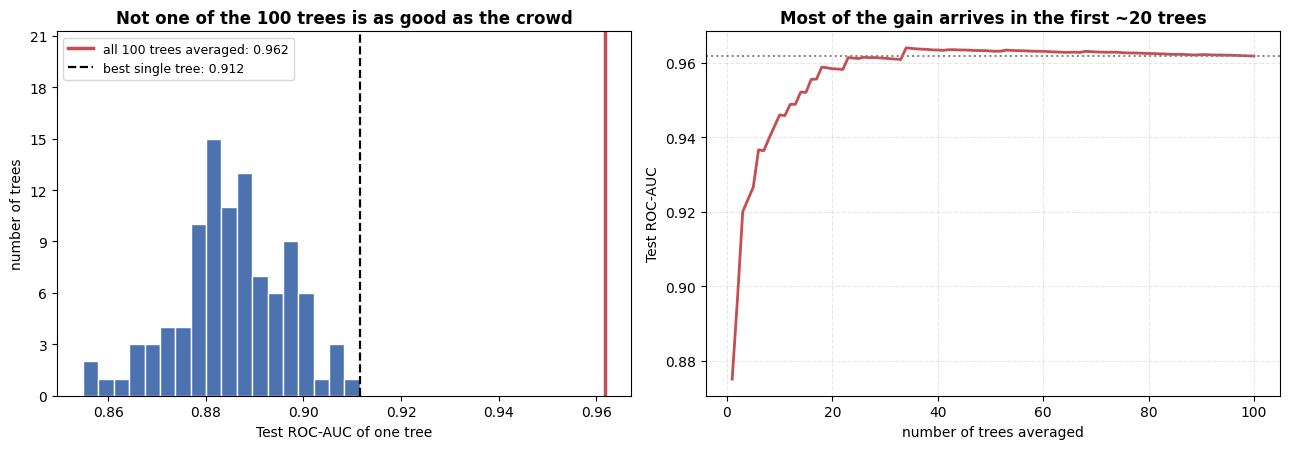


📊 Step table: how AUC grows as trees are added
  trees   test ROC-AUC
-----------------------
      1         0.8750
      2         0.8965
      5         0.9265
     10         0.9459
     25         0.9611
     50         0.9631
    100         0.9617

 Single trees: worst 0.8549, median 0.8856, best 0.9115
 The 100-tree average reproduces rf.predict_proba to within 0.00e+00
 - so this really is the same model, taken apart.


In [3]:
# CELL: Show that the "forest" part is doing the work, not the "tree" part.
# WHY: this notebook trains 100 trees and never shows what the 100 buys you.
# The 100 trees are already fitted, so this costs no extra training - we just
# score them one at a time and then average them one at a time.

# Each fitted tree's own probability for every test transaction: (n_test, 100)
tree_probs = np.column_stack([t.predict_proba(X_test)[:, 1] for t in rf.estimators_])
single_aucs = np.array([roc_auc_score(y_test, tree_probs[:, i])
                        for i in range(tree_probs.shape[1])])

# Averaging the first n trees IS what a forest of n trees predicts.
running_mean = np.cumsum(tree_probs, axis=1) / np.arange(1, tree_probs.shape[1] + 1)
auc_by_n = np.array([roc_auc_score(y_test, running_mean[:, i])
                     for i in range(running_mean.shape[1])])
forest_auc = roc_auc_score(y_test, rf_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Panel 1: every individual tree, and the crowd
ax = axes[0]
ax.hist(single_aucs, bins=18, color='#4C72B0', edgecolor='white')
ax.axvline(forest_auc, color='#C44E52', linewidth=2.5,
           label=f'all 100 trees averaged: {forest_auc:.3f}')
ax.axvline(single_aucs.max(), color='black', linestyle='--', linewidth=1.6,
           label=f'best single tree: {single_aucs.max():.3f}')
ax.set_xlabel('Test ROC-AUC of one tree')
ax.set_ylabel('number of trees')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # counts are whole numbers
ax.set_title('Not one of the 100 trees is as good as the crowd',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, ax.get_ylim()[1] * 1.35)   # headroom so the legend clears the bars
ax.legend(fontsize=9, loc='upper left')

# --- Panel 2: watch the crowd converge as trees are added
ax = axes[1]
ax.plot(np.arange(1, len(auc_by_n) + 1), auc_by_n, color='#C44E52', linewidth=2)
ax.axhline(forest_auc, color='gray', linestyle=':', linewidth=1.4)
ax.set_xlabel('number of trees averaged')
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Most of the gain arrives in the first ~20 trees',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

fig.tight_layout()
plt.show()

print("\n📊 Step table: how AUC grows as trees are added")
print(f"{'trees':>7} {'test ROC-AUC':>14}")
print("-" * 23)
for n in [1, 2, 5, 10, 25, 50, 100]:
    print(f"{n:>7d} {auc_by_n[n - 1]:>14.4f}")
print(f"\n Single trees: worst {single_aucs.min():.4f}, "
      f"median {np.median(single_aucs):.4f}, best {single_aucs.max():.4f}")
print(f" The 100-tree average reproduces rf.predict_proba to within "
      f"{np.abs(running_mean[:, -1] - rf_pred_proba).max():.2e}")
print(" - so this really is the same model, taken apart.")


**Read the figure.** Left: each bar counts trees that scored in that AUC range on their own. The whole histogram sits to the *left* of the red line — the averaged forest beats every one of its own members, including the best one (black dashed). That is the entire argument for an ensemble: individually mediocre, collectively strong, because the trees make *different* mistakes and averaging cancels them.

Right: the same 100 trees added one at a time. The curve climbs steeply and then flattens onto the dotted line, which is the finished forest. Read the step table under the plot for the exact numbers — the practical lesson is that `n_estimators` has strongly diminishing returns, so the honest question is not "how many trees can I afford" but "where does this curve stop climbing".

## Part 2: Naive Bayes for Text Classification — Routing Real 911 Calls

Naive Bayes on word counts is the classic spam-filter algorithm, and it is used here on
real text of the same shape: the short description a dispatcher types for each 911 call
(`"CARDIAC EMERGENCY"`, `"VEHICLE ACCIDENT"`, `"GAS-ODOR/LEAK"`). Every call in the
Montgomery County log carries a category — **EMS**, **Fire** or **Traffic** — so we can
train on real descriptions and check the model against the real routing decision.

Same algorithm, same `CountVectorizer` pipeline a spam filter uses; only the labels differ.


In [4]:
# Naive Bayes on REAL dispatch text: route an incident description to EMS / Fire / Traffic.
# WHY this task: it is exactly the spam-filter recipe (word counts -> MultinomialNB), but
# on text a human actually typed under time pressure, with the abbreviations to prove it.
calls = pd.read_csv("../../datasets/raw/montgomery_911_calls.csv",
                    usecols=["title"], nrows=60_000)

# Each title looks like "EMS: BACK PAINS/INJURY" — category before the colon,
# description after it. We train on the description and predict the category.
category = calls["title"].str.split(":").str[0].str.strip()
description = calls["title"].str.split(":").str[1].str.strip()
keep = description.notna()
description, category = description[keep], category[keep]

print(f"Real calls loaded: {len(description):,}")
print(f"Categories: {category.value_counts().to_dict()}")
print(f"Example descriptions: {description.head(4).tolist()}")

text_train, text_test, y_train_txt, y_test_txt = train_test_split(
    description, category, test_size=0.3, random_state=42, stratify=category)

# Convert text into word-count features (fit on the TRAINING text only)
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(text_train)
X_text_test = vectorizer.transform(text_test)

# Train a Multinomial Naive Bayes classifier (well suited to word counts)
nb_model = MultinomialNB()
nb_model.fit(X_text, y_train_txt)

print("=" * 60)
print("Naive Bayes call routing:")
print("=" * 60)
print(f"Vocabulary learned: {len(vectorizer.vocabulary_)} distinct words")
print(f"Test accuracy on {len(text_test):,} held-out calls: "
      f"{nb_model.score(X_text_test, y_test_txt):.4f}")
print("\nPer-category report:")
print(classification_report(y_test_txt, nb_model.predict(X_text_test), digits=3))

# Classify descriptions the model has never seen, written the way a dispatcher would.
new_calls = ["CARDIAC ARREST", "VEHICLE ACCIDENT", "BUILDING FIRE", "unconscious subject"]
new_X = vectorizer.transform(new_calls)
nb_pred = nb_model.predict(new_X)
nb_proba = nb_model.predict_proba(new_X)

print("Routing four unseen descriptions:")
for text, pred, proba in zip(new_calls, nb_pred, nb_proba):
    print(f"  '{text}' -> {pred} (confidence: {proba.max():.4f})")

Real calls loaded: 60,000
Categories: {'EMS': 29551, 'Traffic': 21580, 'Fire': 8869}
Example descriptions: ['BACK PAINS/INJURY', 'DIABETIC EMERGENCY', 'GAS-ODOR/LEAK', 'CARDIAC EMERGENCY']
Naive Bayes call routing:
Vocabulary learned: 109 distinct words
Test accuracy on 18,000 held-out calls: 0.9313

Per-category report:


              precision    recall  f1-score   support

         EMS      0.998     0.912     0.953      8865
        Fire      0.907     0.871     0.889      2661
     Traffic      0.866     0.982     0.921      6474

    accuracy                          0.931     18000
   macro avg      0.924     0.922     0.921     18000
weighted avg      0.937     0.931     0.932     18000

Routing four unseen descriptions:
  'CARDIAC ARREST' -> EMS (confidence: 0.9999)
  'VEHICLE ACCIDENT' -> Traffic (confidence: 0.9769)
  'BUILDING FIRE' -> Fire (confidence: 0.9965)
  'unconscious subject' -> EMS (confidence: 1.0000)


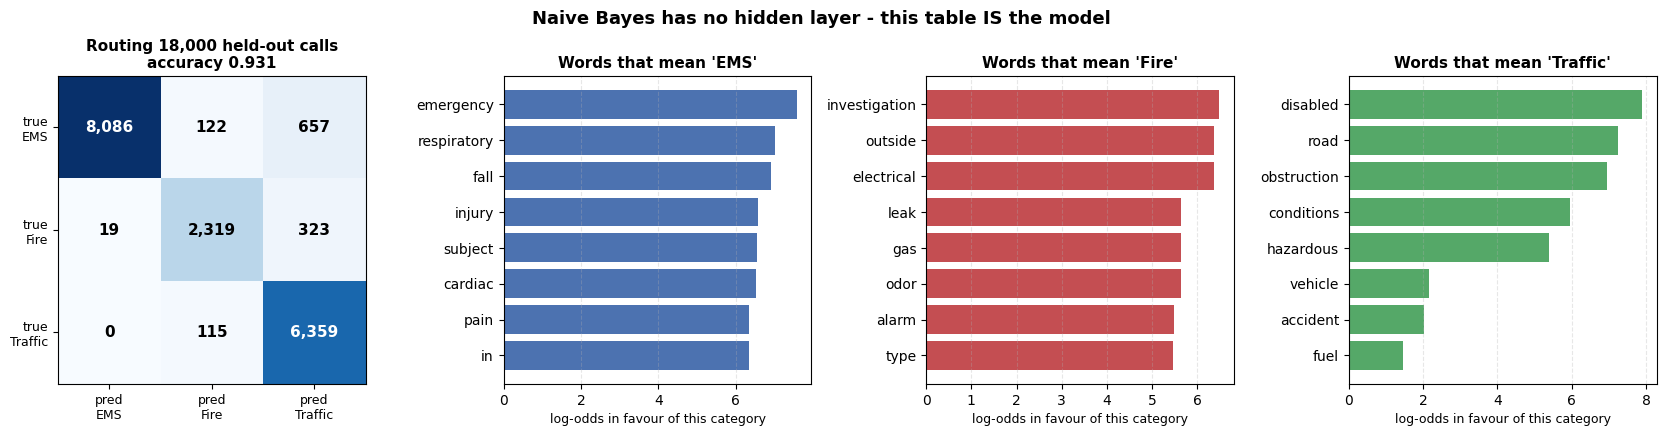


📊 The top evidence word for each category, with its log-odds:
  EMS        'emergency'  +7.58
  Fire       'investigation'  +6.49
  Traffic    'disabled'  +7.89

💡 A positive bar means: seeing this word makes that category more likely.
   Naive Bayes simply adds these numbers up over the words in the call text.


In [5]:
# CELL: Show what Naive Bayes actually learned, not just how often it is right.
# WHY: the whole appeal of this model is that its "reasoning" is a table of word
# probabilities you can read. feature_log_prob_ IS that table - one row per
# category, one column per vocabulary word.

vocab = np.array(vectorizer.get_feature_names_out())
log_prob = nb_model.feature_log_prob_        # shape: (3 categories, n_words)
classes = list(nb_model.classes_)

# How much MORE likely is a word under this category than under the others?
# (log space, so this subtraction is a ratio.) That is the evidence the model
# adds up when it routes a call.
others_mean = np.array([np.delete(log_prob, i, axis=0).mean(axis=0)
                        for i in range(len(classes))])
evidence = log_prob - others_mean

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4),
                         gridspec_kw={'width_ratios': [1.15, 1, 1, 1]})

# --- Panel 1: where the routing goes wrong
y_pred_txt = nb_model.predict(X_text_test)
cm_txt = confusion_matrix(y_test_txt, y_pred_txt, labels=classes)
ax = axes[0]
ax.imshow(cm_txt, cmap="Blues")
ax.set_xticks(range(len(classes)), labels=[f"pred\n{c}" for c in classes], fontsize=9)
ax.set_yticks(range(len(classes)), labels=[f"true\n{c}" for c in classes], fontsize=9)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm_txt[i, j]:,}", ha="center", va="center", fontsize=11,
                fontweight="bold",
                color="white" if cm_txt[i, j] > cm_txt.max() / 2 else "black")
ax.set_title(f"Routing {len(y_test_txt):,} held-out calls\n"
             f"accuracy {nb_model.score(X_text_test, y_test_txt):.3f}",
             fontsize=11, fontweight="bold")

# --- Panels 2-4: the words that decide each category
bar_colors = ['#4C72B0', '#C44E52', '#55A868']
for ax, ci, colr in zip(axes[1:], range(len(classes)), bar_colors):
    top = np.argsort(evidence[ci])[-8:]          # 8 most category-specific words
    ax.barh(range(len(top)), evidence[ci][top], color=colr)
    ax.set_yticks(range(len(top)), labels=vocab[top], fontsize=10)
    ax.set_xlabel('log-odds in favour of this category', fontsize=9)
    ax.set_title(f"Words that mean '{classes[ci]}'", fontsize=11, fontweight="bold")
    ax.grid(axis='x', alpha=0.3, linestyle='--')

fig.suptitle("Naive Bayes has no hidden layer - this table IS the model",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("\n📊 The top evidence word for each category, with its log-odds:")
for ci, c in enumerate(classes):
    j = int(np.argmax(evidence[ci]))
    print(f"  {c:<10} '{vocab[j]}'  {evidence[ci][j]:+.2f}")
print("\n💡 A positive bar means: seeing this word makes that category more likely.")
print("   Naive Bayes simply adds these numbers up over the words in the call text.")


**Read the figure.** The left panel is the routing decision on held-out calls: the diagonal is what went to the right desk, everything off it went to the wrong one. Look at which off-diagonal cells are largest — that pair of categories is where the vocabulary genuinely overlaps.

The three bar panels are the model itself. Each bar is a word, and its length is how much more likely that word is under this category than under the other two. This is not an explanation bolted on afterwards; it is the actual arithmetic — Naive Bayes adds these numbers up over the words in a call description and picks the largest total. Read the words out loud and you can audit it. Most are exactly what you would hope for - but look at 'in' sitting in the EMS list, a word with no medical content that simply happens to appear in EMS phrasing. That is the model latching onto surface form rather than meaning, and spotting it in a bar chart is why this figure is worth drawing at all.

## Part 3: Evaluation Metrics - Confusion Matrix and ROC Curve

Back to the fraud detector. On data this unbalanced the four confusion-matrix cells matter
far more than the single accuracy number: every **false negative** is a fraud that went
through, and every **false positive** is a customer whose legitimate card got blocked.


ROC Curve Analysis:
ROC AUC Score: 0.9617
True Positive Rate at FPR=0.2: 0.9401

Confusion Matrix Interpretation:
True Negatives (TN): 5996
False Positives (FP): 4
False Negatives (FN): 30
True Positives (TP): 118

Precision: 0.9672
Recall: 0.7973
F1-Score: 0.8741


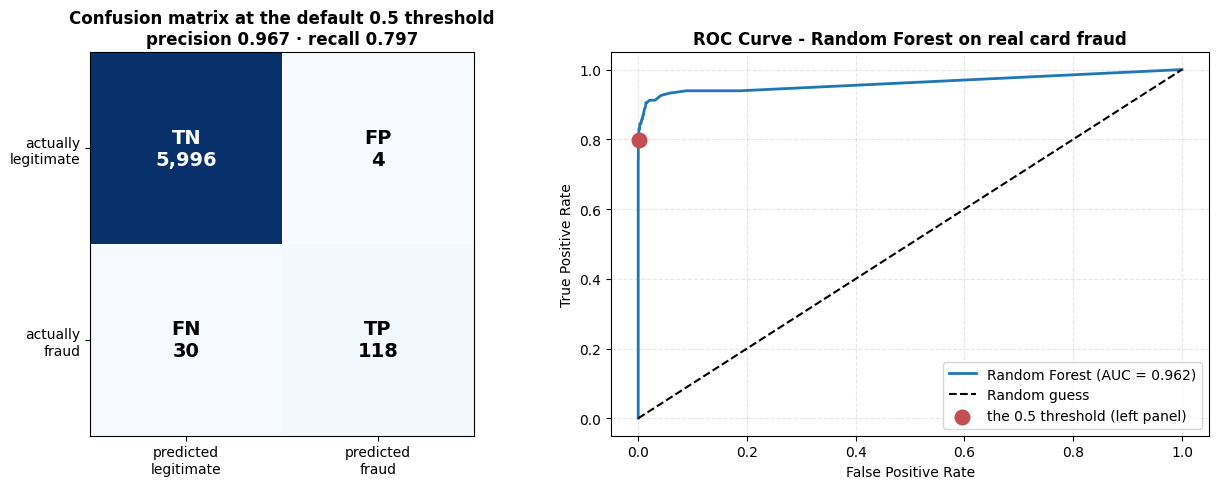

In [6]:
# ROC Curve for Random Forest
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)
print("=" * 60)
print("ROC Curve Analysis:")
print("=" * 60)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"True Positive Rate at FPR=0.2: {np.interp(0.2, fpr, tpr):.4f}")

# Confusion matrix interpretation
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f}")


# Draw both halves of the story: WHERE the errors fall, and how the model
# trades one kind of error for the other as the threshold moves.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: the confusion matrix the markdown above talks about
ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
labels = ["legitimate", "fraud"]
ax.set_xticks([0, 1], labels=[f"predicted\n{t}" for t in labels])
ax.set_yticks([0, 1], labels=[f"actually\n{t}" for t in labels])
names = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        # white text on the dark cell, black on the pale ones
        ax.text(j, i, f"{names[i][j]}\n{cm[i, j]:,}", ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title(f"Confusion matrix at the default 0.5 threshold\n"
             f"precision {tp/(tp+fp):.3f} · recall {tp/(tp+fn):.3f}",
             fontsize=12, fontweight="bold")

# --- Panel 2: the ROC curve (unchanged content, now beside its matrix)
ax = axes[1]
ax.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
# mark the operating point the confusion matrix on the left corresponds to
ax.scatter([fp / (fp + tn)], [tp / (tp + fn)], s=110, color="#C44E52", zorder=5,
           label="the 0.5 threshold (left panel)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Random Forest on real card fraud",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, linestyle="--")

fig.tight_layout()
plt.show()


**Read the figure.** Left, the four cells the section above insists on. TN is huge and TP is small — that is what a 1-in-42 fraud rate looks like, and it is exactly why the accuracy number printed further up is useless here. The two cells to watch are FN (frauds that went through) and FP (real customers whose card got blocked); the precision and recall in the panel title are just those two cells, rewritten.

Right, the same model at *every* threshold instead of just 0.5. The red dot marks the exact operating point the left panel counts, and it sits hard against the left edge — this forest catches most fraud while barely touching legitimate traffic. Moving the dot up that steep left edge costs almost nothing; moving it along the long flat stretch to the right costs a great deal for very little extra recall.

## 💬 Discuss

From the confusion matrix: TN **5996**, FP **4**, FN **30**, TP **118**. Naive Bayes call routing:
accuracy **0.9313**, per-category recall EMS 0.912, Fire 0.871, Traffic 0.982.

1. **Put money on the errors.** The forest catches 118 frauds and raises 4 false alarms; the
   do-nothing model catches 0 and raises 0. If a missed fraud averages 1,000 SAR and a false alarm
   costs 20 SAR of support time, which model wins? Now set the false-alarm cost to 200 SAR and
   recompute. Does your recommendation flip, and at what exchange rate between the two errors does it
   flip exactly?

2. **`'unconscious subject'` is routed to EMS with confidence 1.0000**, from a vocabulary of 109
   words. Is that confidence real? Explain what a probability of 1.0 can possibly mean from a model
   whose independence assumption you already know is false — and what you would show a dispatcher
   instead of that number.

3. **Fire recall is 0.871** — roughly one fire call in eight is routed elsewhere; EMS recall is 0.912;
   Traffic recall is 0.982. You have one week. Do you spend it lifting overall accuracy from 93.1% to
   95%, or lifting Fire recall alone? Justify with consequences, not with metrics.


## Summary

### Key Concepts:
1. **Random Forest**: Ensemble of decision trees, reduces overfitting
2. **Naive Bayes**: Probabilistic classifier, excellent for text classification
3. **Confusion Matrix**: Shows TP, TN, FP, FN for detailed evaluation
4. **ROC Curve**: Plots TPR vs FPR, AUC score summarizes performance

### Applications:
- Random Forest: general tabular classification — here, real card-fraud detection
- Naive Bayes: spam detection, text classification, document categorization — here, routing real 911 call descriptions

### What the real data added:
- **Accuracy lied.** Flagging nothing as fraud already scores ~0.976 on the test split; only precision, recall and AUC show whether the model is doing anything.
- **Text is messy.** Dispatchers write in abbreviations and slashes, and the vocabulary is tiny compared with prose — Naive Bayes copes because word counts are all it ever needed.

**Reference:** Course 04, Unit 3: "Applying random forest classifiers" and "Implementing Naive Bayes for text classification"


## ⚠️ Where this breaks

- **Naive Bayes' probabilities are systematically extreme.** It multiplies per-word probabilities as
  though the words were independent, so evidence gets counted several times over and confidences pile
  up at 0 and 1. Treat its **ranking** as informative and its **probability** as decoration — or
  calibrate it explicitly before anyone acts on the number.
- **It only knows the words it saw.** The vocabulary here is 109 words. A dispatcher who types a
  phrasing that never appeared in training contributes nothing to the decision, and the model will not
  tell you that it is guessing.
- **Random Forest's limit is the mirror image.** It is the more accurate model here and you cannot
  show a fraud investigator why *this* transaction was flagged. Feature importances describe the
  forest as a whole, not the case in front of you.
- **The assumption that must hold for the fraud result:** that fraud in a two-day capture from
  September 2013 resembles fraud today. It does not. Fraud adapts specifically to whatever is
  currently being detected, which is why production fraud models are retrained continuously and
  monitored for drift — the one thing this notebook cannot demonstrate.
- **The cheaper alternative for text:** a linear model on TF-IDF features (`LogisticRegression` or
  `LinearSVC`) usually beats Naive Bayes on accuracy *and* gives usable probabilities, for a few
  seconds more training. Naive Bayes earns its place when training data is tiny, when you need it to
  train in milliseconds, or when it must update online, one message at a time.


## 📚 References

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
2. Domingos, P., & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss*. Machine Learning, 29, 103–130.
3. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. <https://arxiv.org/abs/2511.08667>
